# Stock Clustering Using DBSCAN and K-Means

**Unsupervised machine learning applied to equity risk–return profiles**

This mini-project groups a diversified universe of U.S. stocks using four historical financial features: annualized return, annualized volatility, maximum drawdown, and market beta. It compares two clustering approaches:

- **DBSCAN**, which discovers dense regions and identifies unusual stocks as noise.
- **K-Means**, which assigns every stock to one of a chosen number of clusters.

The objective is not to predict returns or recommend investments. It is to demonstrate a complete unsupervised-learning workflow and interpret the resulting groups in financial terms.


## 1. Methodology

1. Download five years of adjusted daily prices from Yahoo Finance.
2. Engineer four risk–return features for each stock.
3. Standardize the features because both algorithms rely on distances.
4. Use a k-distance plot to guide the DBSCAN `eps` choice.
5. Use elbow and silhouette analyses to select the number of K-Means clusters.
6. Compare the algorithms and interpret the resulting stock profiles.

### Financial features

| Feature | Definition | Interpretation |
|---|---|---|
| Annualized return | Mean daily return × 252 | Historical average return |
| Annualized volatility | Daily standard deviation × √252 | Total return variability |
| Maximum drawdown | Largest peak-to-trough decline | Historical downside severity |
| Beta | Cov(stock, SPY) / Var(SPY) | Sensitivity to broad-market returns |


## 2. Setup


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TRADING_DAYS = 252

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


## 3. Stock universe and market data


In [2]:
tickers = [
    # Technology
    "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "ORCL",
    # Financials
    "JPM", "BAC", "GS", "MS", "V", "MA",
    # Healthcare
    "JNJ", "PFE", "MRK", "UNH", "ABBV", "LLY",
    # Consumer
    "WMT", "COST", "PG", "KO", "MCD", "NKE",
    # Industrials and energy
    "CAT", "GE", "BA", "XOM", "CVX", "COP",
    # Higher-risk growth stocks
    "TSLA", "AMD", "PLTR", "COIN",
]

benchmark = "SPY"
all_tickers = tickers + [benchmark]

raw = yf.download(
    all_tickers,
    period="5y",
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise RuntimeError("No market data were downloaded. Check the connection and ticker list.")

prices = raw["Close"].copy().dropna(axis=1, how="all")
missing_tickers = sorted(set(all_tickers) - set(prices.columns))

print(f"Observation window: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Missing tickers: {missing_tickers or 'None'}")
prices.tail()


Observation window: 2021-08-19 to 2026-08-19
Missing tickers: None


Ticker,AAPL,ABBV,AMD,AVGO,BA,BAC,CAT,COIN,COP,COST,...,ORCL,PFE,PG,PLTR,SPY,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-08-13,305.260,250.820,483.010,417.820,230.330,64.090,854.600,153.900,123.695,961.850,...,156.220,26.800,144.260,179.010,777.880,339.960,399.060,365.450,115.720,157.590
2026-08-14,305.930,249.460,514.390,392.990,231.670,64.490,856.570,148.470,125.940,961.100,...,150.520,26.790,144.550,174.040,776.340,342.270,401.730,364.150,115.270,159.070
2026-08-17,305.590,250.330,506.000,392.430,225.950,63.890,881.650,150.550,127.560,953.500,...,146.650,26.870,143.120,172.550,772.670,339.300,395.620,358.840,114.330,161.460
2026-08-18,310.030,258.920,484.390,380.000,223.060,64.230,840.870,146.230,129.720,961.350,...,142.790,27.250,143.450,171.540,767.450,336.870,393.930,364.250,115.200,165.560
2026-08-19,316.910,265.790,463.245,359.865,221.970,64.030,807.490,152.520,131.560,976.790,...,137.470,28.338,146.100,170.660,769.120,337.695,393.770,369.880,116.490,167.905


`auto_adjust=True` adjusts prices for corporate actions such as splits and dividends. The five-year window is rolling, so results may change when the notebook is rerun at a later date.


## 4. Feature engineering


In [3]:
daily_returns = prices.pct_change(fill_method=None)

annual_return = daily_returns.mean() * TRADING_DAYS
annual_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS)

running_max = prices.cummax()
drawdowns = prices.div(running_max).sub(1)
max_drawdown = drawdowns.min()

market_returns = daily_returns[benchmark]
beta = daily_returns.apply(
    lambda stock_returns: stock_returns.cov(market_returns) / market_returns.var()
)

feature_columns = [
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "beta",
]

features = pd.DataFrame(
    {
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "max_drawdown": max_drawdown,
        "beta": beta,
    }
).drop(index=benchmark, errors="ignore").dropna()

features_display = features.copy()
features_display[["annual_return", "annual_volatility", "max_drawdown"]] *= 100
features_display.columns = ["Annual Return (%)", "Annual Volatility (%)", "Max Drawdown (%)", "Beta"]

features_display.round(2)


,Annual Return (%),Annual Volatility (%),Max Drawdown (%),Beta
Ticker,,,,
AAPL,19.900,28.050,-33.360,1.180
ABBV,22.820,23.530,-21.920,0.300
AMD,46.190,57.090,-65.450,2.150
AVGO,52.340,44.230,-41.150,1.650
BA,7.630,36.690,-50.290,1.140
BAC,15.360,26.610,-46.640,0.950
CAT,34.370,31.790,-34.050,1.060
COIN,26.770,86.020,-90.900,2.690
COP,27.430,32.730,-36.300,0.610


### Feature relationships


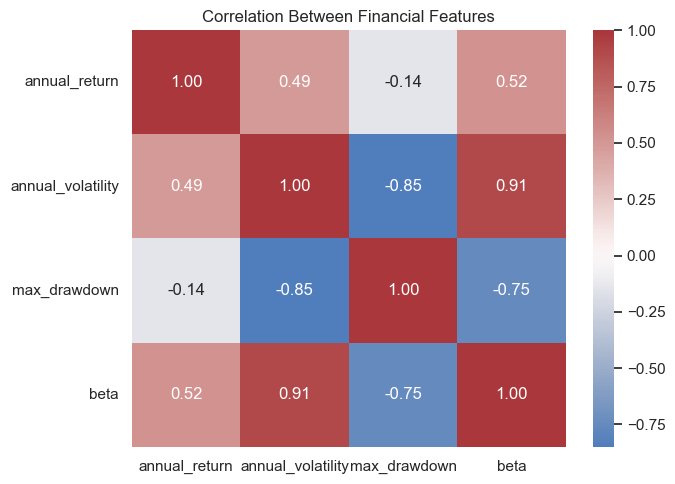

In [4]:
plt.figure(figsize=(7, 5))
sns.heatmap(features.corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation Between Financial Features")
plt.tight_layout()
plt.show()


Return, volatility, drawdown, and beta may be correlated, but they capture different aspects of a stock's historical profile. Because their scales differ, the next step standardizes them before calculating distances.


## 5. Feature standardization


In [5]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(features[feature_columns]),
    index=features.index,
    columns=feature_columns,
)

X_scaled.describe().round(2)


,annual_return,annual_volatility,max_drawdown,beta
count,34.000,34.000,34.000,34.000
mean,0.000,-0.000,0.000,0.000
std,1.020,1.020,1.020,1.020
min,-2.480,-1.100,-2.460,-1.290
25%,-0.520,-0.610,-0.820,-0.890
50%,-0.100,-0.330,0.320,-0.100
75%,0.310,0.210,0.850,0.310
max,2.350,3.490,1.310,2.690


After standardization, each feature has approximately zero mean and unit standard deviation. This prevents a feature with a larger numerical scale from dominating the Euclidean distance.


## 6. DBSCAN clustering


DBSCAN defines dense regions using two parameters:

- `eps`: the maximum neighborhood radius.
- `min_samples`: the minimum number of observations required to form a dense region, including the observation itself.

With four features, this project uses `min_samples = 5` as a practical starting point.


### 6.1 K-distance plot for selecting `eps`


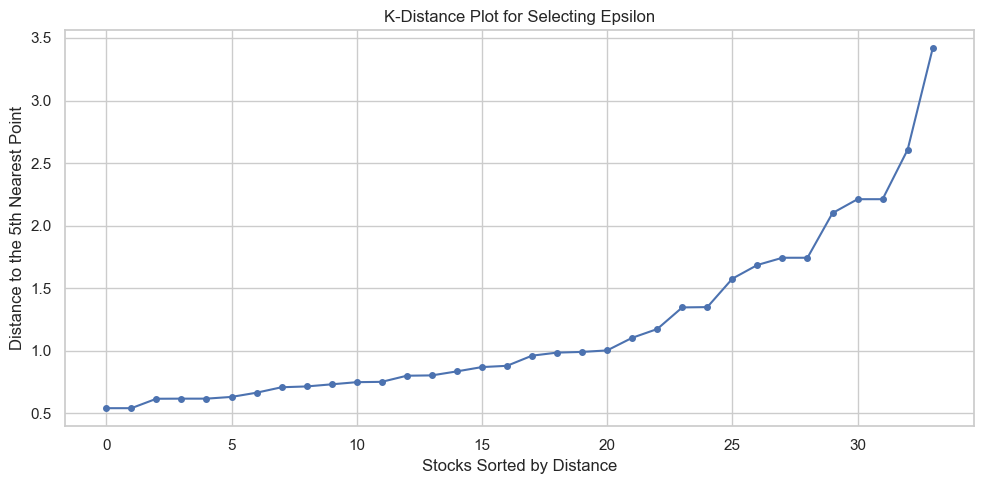

,ticker,k_distance
24,CRM,1.350
25,PFE,1.577
26,ORCL,1.686
27,AVGO,1.744
28,AMD,1.744
29,NKE,2.101
30,TSLA,2.212
31,NVDA,2.212
32,PLTR,2.608
33,COIN,3.417


In [6]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

k_distance_table = (
    pd.DataFrame(
        {
            "ticker": X_scaled.index,
            "k_distance": distances[:, -1],
        }
    )
    .sort_values("k_distance")
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
plt.plot(k_distance_table.index, k_distance_table["k_distance"], marker="o", markersize=4)
plt.xlabel("Stocks Sorted by Distance")
plt.ylabel("Distance to the 5th Nearest Point")
plt.title("K-Distance Plot for Selecting Epsilon")
plt.tight_layout()
plt.show()

k_distance_table.tail(10)


Each stock is one point in a four-dimensional feature space. 
For each stock, the chart reports the distance to its fifth nearest point, including the stock itself—equivalently, its fourth nearest *other* stock. Stocks on the left lie in denser regions; those on the right are more isolated. The point where distances begin to rise sharply provides a starting estimate for `eps`.


### 6.2 Parameter sensitivity


In [7]:
eps_values = [1.4, 1.6, 1.7, 1.8, 2.0]
dbscan_sensitivity = []

for eps_value in eps_values:
    labels = DBSCAN(eps=eps_value, min_samples=min_samples).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    dbscan_sensitivity.append(
        {"eps": eps_value, "clusters": n_clusters, "noise_stocks": n_noise}
    )

pd.DataFrame(dbscan_sensitivity)


,eps,clusters,noise_stocks
0,1.400,1,7
1,1.600,1,6
2,1.700,1,5
3,1.800,1,1
4,2.000,1,1


### 6.3 Final DBSCAN model


In [8]:
selected_eps = 1.7
dbscan = DBSCAN(eps=selected_eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_results = features.copy()
dbscan_results["dbscan_cluster"] = dbscan_labels

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_stocks = dbscan_results.index[dbscan_results["dbscan_cluster"] == -1].tolist()

print(f"Clusters: {n_dbscan_clusters}")
print(f"Noise stocks ({len(noise_stocks)}): {noise_stocks}")

dbscan_results.sort_values("dbscan_cluster").round(3)


Clusters: 1
Noise stocks (5): ['AMD', 'COIN', 'NVDA', 'PLTR', 'TSLA']


,annual_return,annual_volatility,max_drawdown,beta,dbscan_cluster
Ticker,,,,,
AMD,0.462,0.571,-0.654,2.154,-1
TSLA,0.259,0.596,-0.736,2.026,-1
PLTR,0.612,0.670,-0.791,2.089,-1
COIN,0.268,0.860,-0.909,2.690,-1
NVDA,0.616,0.519,-0.663,2.137,-1
AAPL,0.199,0.280,-0.334,1.176,0
MRK,0.194,0.247,-0.434,0.276,0
MS,0.222,0.288,-0.324,1.166,0
MSFT,0.145,0.282,-0.371,1.129,0


### DBSCAN interpretation

At the selected parameter values, DBSCAN identifies one main connected region and a small set of noise stocks. This indicates that most observations form a continuous risk–return spectrum rather than several clearly separated dense groups.

For this dataset, DBSCAN is therefore more informative as an **outlier-detection method** than as a method for assigning stocks to several distinct categories. The noise label does not imply that a stock is undesirable; it means only that its feature combination is relatively unusual in this sample.


## 7. K-Means clustering


K-Means partitions every observation into one of `k` clusters by minimizing within-cluster squared distances to the cluster centroids. Unlike DBSCAN, it does not identify noise, and `k` must be selected in advance.


### 7.1 Selecting the number of clusters


  File "C:\Users\kkolaro\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\kkolaro\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kkolaro\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\kkolaro\AppData\Local\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


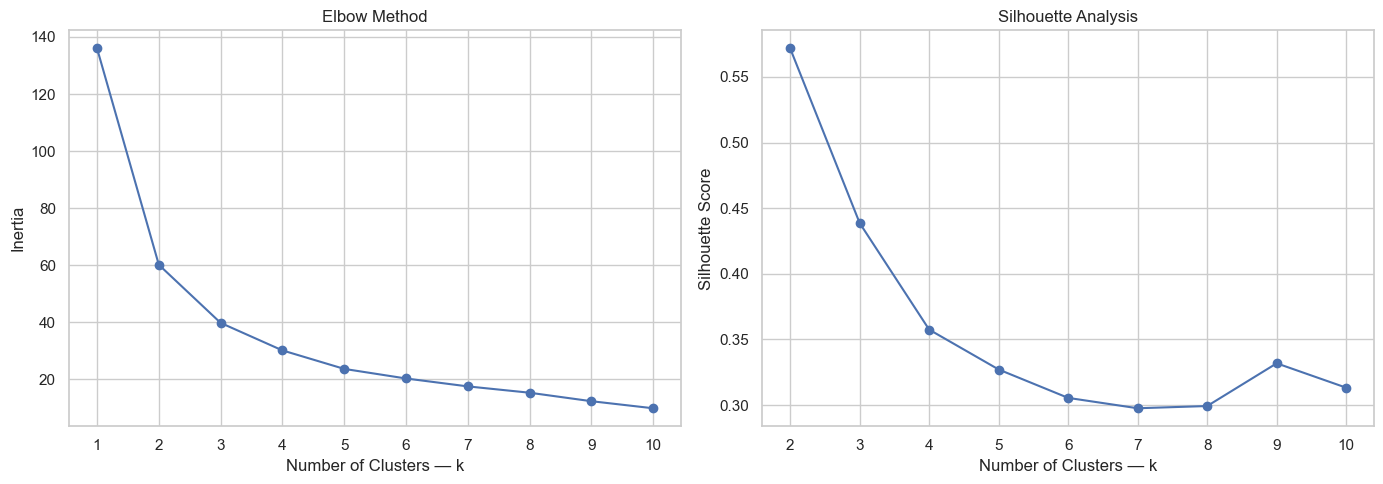

,k,silhouette_score
0,2,0.572
1,3,0.439
2,4,0.357
3,5,0.327
4,6,0.305
5,7,0.298
6,8,0.299
7,9,0.332
8,10,0.313


In [9]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

silhouette_k_values = range(2, 11)
silhouette_scores = []

for k in silhouette_k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_xlabel("Number of Clusters — k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(k_values))

axes[1].plot(list(silhouette_k_values), silhouette_scores, marker="o")
axes[1].set_xlabel("Number of Clusters — k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].set_xticks(list(silhouette_k_values))

plt.tight_layout()
plt.show()

silhouette_table = pd.DataFrame(
    {"k": list(silhouette_k_values), "silhouette_score": silhouette_scores}
)
silhouette_table


The silhouette score compares an observation's cohesion within its assigned cluster with its separation from the nearest alternative cluster. Values closer to 1 indicate more compact and better-separated clusters.

The highest silhouette score occurs at `k = 2`, indicating that two broad groups provide the clearest separation for this sample.


### 7.2 Final K-Means model


In [10]:
selected_k = 2
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=10,
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_results = features.copy()
kmeans_results["cluster"] = kmeans_labels

for cluster_id in sorted(kmeans_results["cluster"].unique()):
    cluster_stocks = kmeans_results.index[
        kmeans_results["cluster"] == cluster_id
    ].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_stocks)} stocks):")
    print(", ".join(cluster_stocks))
    print()


Cluster 0 (6 stocks):
AMD, AVGO, COIN, NVDA, PLTR, TSLA

Cluster 1 (28 stocks):
AAPL, ABBV, BA, BAC, CAT, COP, COST, CRM, CVX, GE, GS, JNJ, JPM, KO, LLY, MA, MCD, MRK, MS, MSFT, NKE, ORCL, PFE, PG, UNH, V, WMT, XOM



### 7.3 Cluster profiles


In [11]:
cluster_profile = kmeans_results.groupby("cluster")[feature_columns].mean()

cluster_profile_display = cluster_profile.copy()
cluster_profile_display[["annual_return", "annual_volatility", "max_drawdown"]] *= 100
cluster_profile_display.columns = [
    "Annual Return (%)",
    "Annual Volatility (%)",
    "Max Drawdown (%)",
    "Beta",
]

cluster_profile_display.round(2)


,Annual Return (%),Annual Volatility (%),Max Drawdown (%),Beta
cluster,,,,
0,45.660,60.970,-69.430,2.120
1,16.880,27.360,-37.240,0.730


The two clusters can be interpreted economically:

- **Cluster 0 — Moderate-risk stocks:** lower market sensitivity, lower volatility, smaller drawdowns, and more moderate historical returns.
- **Cluster 1 — Aggressive high-risk stocks:** substantially higher historical returns, but also much higher volatility, deeper drawdowns, and greater systematic risk.

Cluster numbers are arbitrary labels. Their meanings come from the observed financial profiles, not from the values `0` and `1` themselves.


### 7.4 Two-dimensional visualization using PCA


In [14]:
pca_results

,PC1,PC2,cluster
Ticker,,,
AAPL,-0.308,0.173,1
ABBV,-1.486,0.620,1
AMD,2.989,0.554,0
AVGO,1.559,1.550,0
BA,0.176,-0.936,1
BAC,-0.309,-0.394,1
CAT,0.033,0.871,1
COIN,4.817,-1.241,0
COP,-0.408,0.443,1


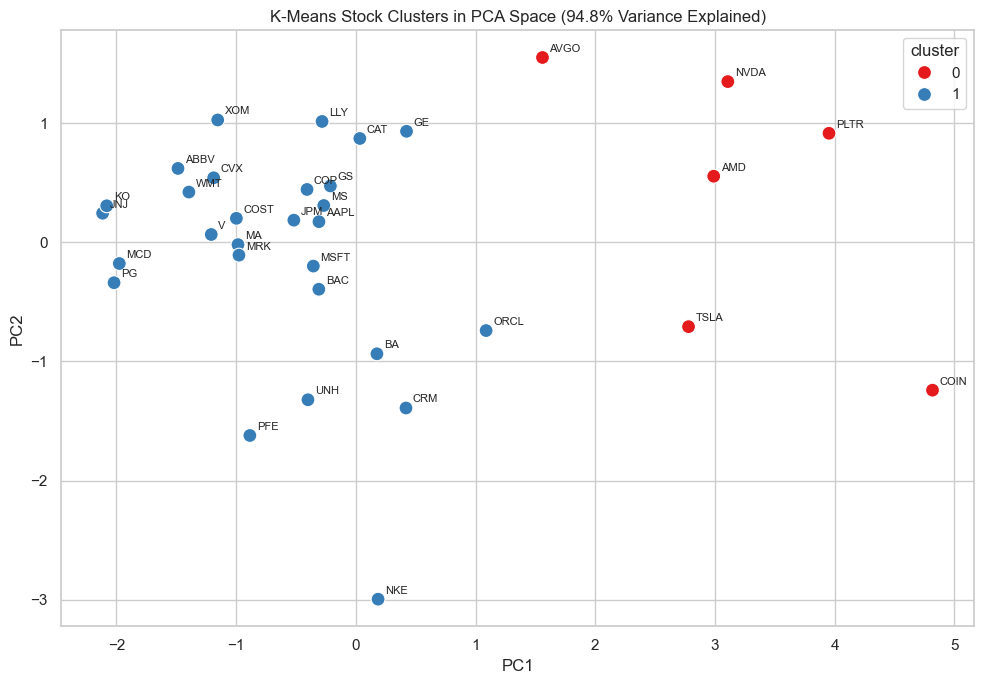

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_results = pd.DataFrame(
    X_pca,
    index=X_scaled.index,
    columns=["PC1", "PC2"],
)
pca_results["cluster"] = kmeans_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_results,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=100,
)

for ticker, row in pca_results.iterrows():
    plt.annotate(
        ticker,
        (row["PC1"], row["PC2"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

explained = pca.explained_variance_ratio_.sum()
plt.title(f"K-Means Stock Clusters in PCA Space ({explained:.1%} Variance Explained)")
plt.tight_layout()
plt.show()


PCA is used only to project the four-dimensional feature space into two dimensions for visualization. K-Means is still fitted on all four standardized features.


## 8. Comparison of the algorithms


| Method | Main result | Best use in this project |
|---|---|---|
| DBSCAN | One dense group plus unusual observations | Identifying outlier risk–return profiles |
| K-Means | Two broad stock groups | Assigning every stock to an interpretable category |

The different results are not contradictory. DBSCAN asks whether the data contain separated dense regions, whereas K-Means imposes a partition into a specified number of groups.


## 9. Limitations


- Results depend on the selected stocks, five-year estimation window, and market regime.
- Historical return is not an expected return and should not be interpreted as a forecast.
- Beta and volatility estimates may be unstable and can change materially over time.
- Euclidean distance and equal feature weighting may not fully represent financial similarity.
- Some features are correlated, so related risk information may receive additional influence.
- K-Means favors roughly spherical clusters and requires the number of clusters in advance.
- DBSCAN is sensitive to `eps`, `min_samples`, and variation in local density.
- Transaction costs, liquidity, valuation, fundamentals, and forward-looking information are not included.


## 10. Conclusion


This project demonstrates how unsupervised machine learning can organize stocks by historical risk–return characteristics without predefined labels.

DBSCAN found one main connected group and several unusual observations, making it more useful for outlier detection in this sample. K-Means produced a clearer two-cluster partition: a moderate-risk group and an aggressive high-risk group. The higher historical returns of the aggressive group were accompanied by substantially greater volatility, drawdown, and market beta.

The analysis is exploratory and educational. It is not investment advice.
